In [9]:
# !pip install transformers
# !pip install jiwer
# !pip install torch
# !pip install Pillow
# !pip install kagglehub
# !pip install IPython
# !pip install scikit-learn
# !pip install pandas
# !pip install tqdm
# !pip install --pre torch torchvision torchaudio --index-url https://download.pytorch.org/whl/nightly/cu128
# !pip install torchvision
# !pip install openpyxl


In [1]:
import torch
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"CUDA version: {torch.version.cuda}")
print(f"GPU count: {torch.cuda.device_count()}")
if torch.cuda.is_available():
    print(f"GPU name: {torch.cuda.get_device_name(0)}")

PyTorch version: 2.12.0.dev20260408+cu128
CUDA available: True
CUDA version: 12.8
GPU count: 1
GPU name: NVIDIA GeForce RTX 5060 Ti


In [2]:
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import TrOCRProcessor, VisionEncoderDecoderModel
from torchvision import transforms
from PIL import Image
import requests
import kagglehub
from IPython.display import display
from sklearn.model_selection import train_test_split
import pandas as pd
import os
from tqdm import tqdm
from jiwer import cer, wer
import torch.nn.utils.rnn as rnn_utils
from transformers import get_linear_schedule_with_warmup
from PIL import ImageEnhance

# Датасет заказчика

## Объединение датасета

In [3]:
import re

def replace_folder(path, correct):
    return re.sub(r'IMG_[\d_]+S', correct, path)

In [4]:
path = 'C:/Users/maill/WORK/Dataset' # указываем тут путь

all_data = []

for root, dirs, files in os.walk(path):
    for file in files:
        if file.endswith(('.xlsx', '.csv')):
            # print(os.path.join(root, file))
            
            full_path = os.path.join(root, file)
            if file.endswith(('.xlsx')):
                df = pd.read_excel(full_path)
            else:
                df = pd.read_csv(full_path, sep=';', on_bad_lines='skip', encoding='utf-8-sig', encoding_errors='replace')

            df['image_path'] = df['image_path'].apply(lambda x: os.path.join(x.replace('\\', '/')) if pd.notna(x) else x)

            #Правим опечатки в путях
            
            main = df['image_path'].iloc[0].split('/')[0]

            df['image_path'] = main + '/' + df['image_path'].str.split('/').str[1]
            # print( df['image_path'] )

            df['image_path'] = root + '/' + df['image_path']

            all_data.append(df)

In [5]:
final_df = pd.concat(all_data, ignore_index=True)

In [6]:
final_df = final_df.drop('Unnamed: 0', axis=1)

In [7]:
# final_df[final_df['label'].isna()]
final_df = final_df.dropna(subset=['image_path'])

In [8]:
df_good = final_df[
    ~final_df['image_path'].str.contains('/5_', na=False, regex=False) &
    ~final_df['image_path'].str.contains('/Text', na=False, regex=False) &
    ~final_df['image_path'].str.contains('/text', na=False, regex=False)
]

In [9]:
print(f'Количество labels = {len(final_df)}')
print('Пустых label:', final_df['label'].isna().sum())
print('Заполненных:', final_df['label'].notna().sum())

Количество labels = 6118
Пустых label: 0
Заполненных: 6118


In [10]:
print(f'Количество четких labels = {len(df_good)}')
print('Пустых четких label:', df_good['label'].isna().sum())
print('Четких Заполненных:', df_good['label'].notna().sum())

Количество четких labels = 3012
Пустых четких label: 0
Четких Заполненных: 3012


# Посмотрим картинки

C:/Users/maill/WORK/Dataset/32_1/img_1


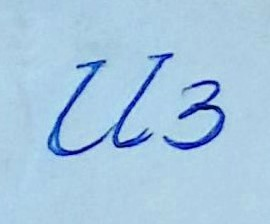

In [11]:
img_path = final_df[final_df['label'].notna()].iloc[0]['image_path']
# img_path = 'C:/Users/maill/WORK/Dataset/5_1/img (150)'
print(img_path)
image = Image.open(img_path + '.jpg').convert('RGB')
display(image)

# Подготавливаем данные

In [14]:
train_df, temp_df = train_test_split(df_good, test_size=0.2, random_state=42, stratify=None)
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42, stratify=None)

In [15]:
train_images = train_df['image_path'].tolist()
train_texts = train_df['label'].astype(str).tolist()

val_images = val_df['image_path'].tolist()
val_texts = val_df['label'].astype(str).tolist()

test_images = test_df['image_path'].tolist()
test_texts = test_df['label'].astype(str).tolist()

In [16]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)

device: cuda


In [17]:
processor = TrOCRProcessor.from_pretrained('kazars24/trocr-base-handwritten-ru')
model = VisionEncoderDecoderModel.from_pretrained('kazars24/trocr-base-handwritten-ru')

model.to(device)

model.config.pad_token_id = processor.tokenizer.pad_token_id
model.config.eos_token_id = processor.tokenizer.eos_token_id
model.config.decoder_start_token_id = processor.tokenizer.cls_token_id

The image processor of type `ViTImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


Loading weights:   0%|          | 0/480 [00:00<?, ?it/s]

In [18]:
class CustomerDataset(Dataset):
    def __init__(self, image_paths, texts, processor, augment=False, enhance_pale=False):
        self.image_paths = []
        self.texts = []
        self.processor = processor
        self.enhance_pale = enhance_pale
        
        for img_path, text in zip(image_paths, texts):
            # Проверяем существует ли файл с каким-либо расширением
            for ext in ['.jpg', '.png', '.jpeg']:
                if os.path.exists(img_path + ext):
                    self.image_paths.append(img_path+ext)
                    self.texts.append(str(text))
                    break

        loaded = len(self.image_paths)
        total = len(image_paths)
        if loaded < total:
            print(f"Загружено {loaded} из {total} изображений (пропущено {total - loaded})")

        if augment:
            self.augmentation = transforms.Compose([
                transforms.RandomRotation(degrees=2), 
                transforms.RandomAffine(degrees=0, translate=(0.03, 0.03)),
                transforms.RandomAutocontrast(p=0.3),
                transforms.ColorJitter(
                    brightness=0.3,      
                    contrast=0.3,        
                    saturation=0.2,      # уменьшаем насыщенность
                    hue=0.05             # легкий сдвиг оттенка
                ),
                
                # transforms.GaussianBlur(kernel_size=(3, 3), sigma=(0.1, 1.0)),
            ])
        else:
            self.augmentation = None

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        text = str(self.texts[idx])
        
        img = Image.open(img_path).convert('RGB')
        
        if self.enhance_pale:
            enhancer = ImageEnhance.Contrast(img)
            img = enhancer.enhance(1.8)  # увеличиваем контраст
            enhancer = ImageEnhance.Brightness(img)
            img = enhancer.enhance(1.3)  # увеличиваем яркость

        if self.augmentation:
            img = self.augmentation(img)
        
        pixel_values = self.processor(images=img, return_tensors='pt').pixel_values[0]
        labels = self.processor(text=text, return_tensors='pt').input_ids[0]
        
        return {'pixel_values': pixel_values, 'labels': labels}

In [19]:
def customer_collate_fn(batch):
    pixel_values = torch.stack([item['pixel_values'] for item in batch])
    labels = [item['labels'] for item in batch]
    
    labels_padded = rnn_utils.pad_sequence(
        labels,
        batch_first=True,
        padding_value=processor.tokenizer.pad_token_id
    )
    
    return {'pixel_values': pixel_values, 'labels': labels_padded}

In [27]:
train_dataset_customer = CustomerDataset(train_images, train_texts, processor, augment=True)
val_dataset_customer = CustomerDataset(val_images, val_texts, processor, augment=False)
test_dataset_customer = CustomerDataset(test_images, test_texts, processor, augment=False)

In [28]:
batch_size = 16 

train_loader = DataLoader(
    train_dataset_customer, 
    batch_size=batch_size, 
    shuffle=True, 
    collate_fn=customer_collate_fn,
    num_workers=0
)

val_loader = DataLoader(
    val_dataset_customer, 
    batch_size=batch_size, 
    shuffle=False, 
    collate_fn=customer_collate_fn,
    num_workers=0
)

test_loader = DataLoader(
    test_dataset_customer, 
    batch_size=batch_size, 
    shuffle=False, 
    collate_fn=customer_collate_fn,
    num_workers=0
)

# model.config.decoder.dropout = 0.05
# model.config.encoder.hidden_dropout_prob = 0.05


## Обучаем

In [29]:
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-5)
EPOCHS = 2
accumulation_steps = 2 

num_training_steps = len(train_loader) * EPOCHS // accumulation_steps
num_warmup_steps = int(0.1 * num_training_steps)

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=num_warmup_steps,
    num_training_steps=num_training_steps
)

In [30]:
best_val_cer = float('inf')
best_val_wer = float('inf')
best_val_loss = float('inf')

for epoch in range(EPOCHS):
    # Train
    model.train()
    train_loss_total = 0
    optimizer.zero_grad()
    
    with tqdm(train_loader, desc=f"Epoch {epoch+1} [Train]") as pbar:
        for i, batch in enumerate(pbar):
            pixel_values = batch['pixel_values'].to(device)
            labels = batch['labels'].to(device)
            
            outputs = model(pixel_values=pixel_values, labels=labels)
            loss = outputs.loss / accumulation_steps
            loss.backward()
            
            train_loss_total += outputs.loss.item() / accumulation_steps
            
            if (i + 1) % accumulation_steps == 0:
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()
                scheduler.step()
                optimizer.zero_grad()
            
            pbar.set_postfix({'loss': f'{outputs.loss.item():.4f}'})
            
            del pixel_values, labels, outputs, loss
    
    avg_train_loss = train_loss_total / len(train_loader)
    
    # Validation
    model.eval()
    val_loss_total = 0
    val_cer_scores = []
    val_wer_scores = []
    
    with torch.no_grad():
        with tqdm(val_loader, desc=f"Epoch {epoch+1} [Val]") as pbar:
            for batch in pbar:
                pixel_values = batch['pixel_values'].to(device)
                labels = batch['labels'].to(device)
                
                outputs = model(pixel_values=pixel_values, labels=labels)
                val_loss_total += outputs.loss.item()
                
                generated_ids = model.generate(
                    pixel_values, 
                    max_length=64,
                    num_beams=2,
                    early_stopping=True
                )
                
                pred_texts = processor.batch_decode(generated_ids, skip_special_tokens=True)
                true_texts = processor.batch_decode(labels, skip_special_tokens=True)
                
                for pred, true in zip(pred_texts, true_texts):
                    val_cer_scores.append(cer(true, pred))
                    val_wer_scores.append(wer(true, pred))
                
                pbar.set_postfix({
                    'val_loss': f'{outputs.loss.item():.4f}',
                    'val_CER': f'{sum(val_cer_scores[-len(pred_texts):])/len(pred_texts):.4f}',
                    'val_WER': f'{sum(val_wer_scores[-len(pred_texts):])/len(pred_texts):.4f}'
                })
                
                del pixel_values, labels, outputs, generated_ids
    
    avg_val_loss = val_loss_total / len(val_loader)
    avg_val_cer = sum(val_cer_scores) / len(val_cer_scores)
    avg_val_wer = sum(val_wer_scores) / len(val_wer_scores)
    
    print(f"Epoch {epoch+1}/{EPOCHS}: Train Loss={avg_train_loss:.4f}, Val Loss={avg_val_loss:.4f}, Val CER={avg_val_cer:.4f}, Val WER={avg_val_wer:.4f}")
    
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        best_val_cer = avg_val_cer
        best_val_wer = avg_val_wer
        model.save_pretrained("./model_customer1")
        processor.save_pretrained("./model_customer1")
        print(f" Сохранена лучшая модель (CER={avg_val_cer:.4f}), WER={avg_val_wer:.4f})")

print(f"Обучение завершено. Лучшие CER: {best_val_cer:.4f}, WER: {best_val_wer:.4f}")

Epoch 1 [Val]: 100%|██████████| 19/19 [00:41<00:00,  2.20s/it, val_loss=0.2787, val_CER=0.3066, val_WER=0.6923]

Epoch 1/2: Train Loss=1.0241, Val Loss=0.2867, Val CER=0.2536, Val WER=0.5493


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

 Сохранена лучшая модель (CER=0.2536), WER=0.5493)


Epoch 2 [Val]: 100%|██████████| 19/19 [00:40<00:00,  2.11s/it, val_loss=0.2445, val_CER=0.2810, val_WER=0.6923]

Epoch 2/2: Train Loss=0.1406, Val Loss=0.2666, Val CER=0.2364, Val WER=0.4922


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

 Сохранена лучшая модель (CER=0.2364), WER=0.4922)
Обучение завершено. Лучшие CER: 0.2364, WER: 0.4922


# Модель на данных каггл

In [31]:
model = VisionEncoderDecoderModel.from_pretrained("./model_customer1")
model.to(device)
model.eval()

Loading weights:   0%|          | 0/480 [00:00<?, ?it/s]

VisionEncoderDecoderModel(
  (encoder): ViTModel(
    (embeddings): ViTEmbeddings(
      (patch_embeddings): ViTPatchEmbeddings(
        (projection): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
      )
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (encoder): ViTEncoder(
      (layer): ModuleList(
        (0-11): 12 x ViTLayer(
          (attention): ViTAttention(
            (attention): ViTSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=False)
              (key): Linear(in_features=768, out_features=768, bias=False)
              (value): Linear(in_features=768, out_features=768, bias=False)
            )
            (output): ViTSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
          )
          (intermediate): ViTIntermediate(
            (dense): Linear(in_features=768, out_features=3072, bias=True)
            (i

In [32]:
test_cer_scores = []
test_wer_scores = []

test_loss_total = 0

with tqdm(test_loader, desc="Testing") as pbar:
    with torch.no_grad():
        for batch in pbar:
            pixel_values = batch['pixel_values'].to(device)
            labels = batch['labels'].to(device)

            generated_ids = model.generate(pixel_values, max_length=32)

            outputs = model(pixel_values=pixel_values, labels=labels)
            test_loss_total += outputs.loss.item()

            pred_texts = processor.batch_decode(generated_ids, skip_special_tokens=True)
            true_texts = processor.batch_decode(labels, skip_special_tokens=True)

            for pred, true in zip(pred_texts, true_texts):
                    test_cer_scores.append(cer(true, pred))
                    test_wer_scores.append(wer(true, pred))
                
            pbar.set_postfix({
                'test_loss': f'{outputs.loss.item():.4f}',
                'test_CER': f'{sum(test_cer_scores[-len(pred_texts):])/len(pred_texts):.4f}',
                'test_WER': f'{sum(test_wer_scores[-len(pred_texts):])/len(pred_texts):.4f}'
            })
           
            del pixel_values, labels, generated_ids, outputs

avg_test_loss = test_loss_total / len(test_loader)
avg_test_cer = sum(test_cer_scores) / len(test_cer_scores)
avg_test_wer = sum(test_wer_scores) / len(test_wer_scores)

print(f"\n=== РЕЗУЛЬТАТЫ ТЕСТИРОВАНИЯ ===")
print(f"Test Loss: {avg_test_loss:.4f}")
print(f"Average CER: {avg_test_cer:.4f}")
print(f"Average WER: {avg_test_wer:.4f}")

Testing: 100%|██████████| 19/19 [01:13<00:00,  3.88s/it, test_loss=0.2138, test_CER=0.1610, test_WER=0.5357]


=== РЕЗУЛЬТАТЫ ТЕСТИРОВАНИЯ ===
Test Loss: 0.2816
Average CER: 0.2221
Average WER: 0.5568


# Модель на данных заказчика

In [33]:
model = VisionEncoderDecoderModel.from_pretrained("./model_customer1")
processor = TrOCRProcessor.from_pretrained("./model_customer1")
model.to(device)
model.eval()

Loading weights:   0%|          | 0/480 [00:00<?, ?it/s]

VisionEncoderDecoderModel(
  (encoder): ViTModel(
    (embeddings): ViTEmbeddings(
      (patch_embeddings): ViTPatchEmbeddings(
        (projection): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
      )
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (encoder): ViTEncoder(
      (layer): ModuleList(
        (0-11): 12 x ViTLayer(
          (attention): ViTAttention(
            (attention): ViTSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=False)
              (key): Linear(in_features=768, out_features=768, bias=False)
              (value): Linear(in_features=768, out_features=768, bias=False)
            )
            (output): ViTSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
          )
          (intermediate): ViTIntermediate(
            (dense): Linear(in_features=768, out_features=3072, bias=True)
            (i

In [34]:
test_cer_scores = []
test_wer_scores = []

test_loss_total = 0

with torch.no_grad():
    with tqdm(test_loader, desc="Testing") as pbar:
        for batch in pbar:
            pixel_values = batch['pixel_values'].to(device)
            labels = batch['labels'].to(device)
            
            generated_ids = model.generate(pixel_values, max_length=64, num_beams=2)
            outputs = model(pixel_values=pixel_values, labels=labels)
            test_loss_total += outputs.loss.item()
            
            pred_texts = processor.batch_decode(generated_ids, skip_special_tokens=True)
            true_texts = processor.batch_decode(labels, skip_special_tokens=True)
            
            for pred, true in zip(pred_texts, true_texts):
                test_cer_scores.append(cer(true, pred))
                test_wer_scores.append(wer(true, pred))
            
            pbar.set_postfix({
                'test_loss': f'{outputs.loss.item():.4f}',
                'test_CER': f'{sum(test_cer_scores[-len(pred_texts):])/len(pred_texts):.4f}',
                'test_WER': f'{sum(test_wer_scores[-len(pred_texts):])/len(pred_texts):.4f}'
            })
           
            del pixel_values, labels, generated_ids, outputs

avg_test_loss = test_loss_total / len(test_loader)
avg_test_cer = sum(test_cer_scores) / len(test_cer_scores)
avg_test_wer = sum(test_wer_scores) / len(test_wer_scores)

print(f"\n=== РЕЗУЛЬТАТЫ ТЕСТИРОВАНИЯ ===")
print(f"Test Loss: {avg_test_loss:.4f}")
print(f"Average CER: {avg_test_cer:.4f}")
print(f"Average WER: {avg_test_wer:.4f}")

Testing: 100%|██████████| 19/19 [00:42<00:00,  2.21s/it, test_loss=0.2138, test_CER=0.1610, test_WER=0.5357]


=== РЕЗУЛЬТАТЫ ТЕСТИРОВАНИЯ ===
Test Loss: 0.2816
Average CER: 0.2286
Average WER: 0.5535


In [35]:
final_df.to_csv('customer_dataset_labels_6118.csv', index=False, encoding='utf-8-sig')

In [20]:
def predict_batch(image_paths, model, processor, device):
    results = []
    for img_path in tqdm(image_paths):
        try:
            image = Image.open(img_path).convert('RGB')

            display(image)

            pixel_values = processor(images=image, return_tensors='pt').pixel_values.to(device)
            generated_ids = model.generate(pixel_values, max_length=64, num_beams=2)
            text = processor.batch_decode(generated_ids, skip_special_tokens=True)[0]
            results.append({'image_path': img_path, 'predicted_text': text})
        except Exception as e:
            print(f"Ошибка на {img_path}: {e}")
            results.append({'image_path': img_path, 'predicted_text': '', 'error': str(e)})
    
    return pd.DataFrame(results)

  0%|          | 0/8 [00:00<?, ?it/s]

 12%|█▎        | 1/8 [00:00<00:02,  3.29it/s]

 25%|██▌       | 2/8 [00:00<00:01,  3.77it/s]

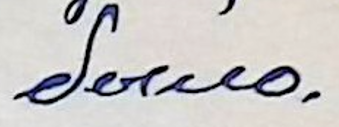

 38%|███▊      | 3/8 [00:00<00:01,  4.18it/s]

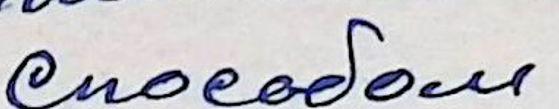

 50%|█████     | 4/8 [00:01<00:01,  3.81it/s]

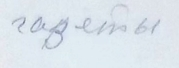

 62%|██████▎   | 5/8 [00:01<00:00,  3.90it/s]

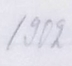

 75%|███████▌  | 6/8 [00:01<00:00,  4.79it/s]

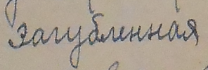

 88%|████████▊ | 7/8 [00:01<00:00,  3.78it/s]

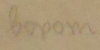

100%|██████████| 8/8 [00:01<00:00,  4.02it/s]

                                          image_path predicted_text
0  C:/Users/maill/WORK/Dataset/IMG_2024_08_08_10_...     уральская,
1  C:/Users/maill/WORK/Dataset/IMG_2024_08_08_10_...         Ардва,
2  C:/Users/maill/WORK/Dataset/IMG_2024_08_08_11_...          было,
3  C:/Users/maill/WORK/Dataset/IMG_2024_08_08_11_...       способом
4        C:/Users/maill/WORK/Dataset/5_1/img (5).jpg         гадеты
5       C:/Users/maill/WORK/Dataset/5_1/img (35).jpg           1909
6      C:/Users/maill/WORK/Dataset/Text_5/img_45.png    Загубленная
7      C:/Users/maill/WORK/Dataset/Text_2/img_49.png         вотрот


In [37]:
image_paths = [
    "C:/Users/maill/WORK/Dataset/IMG_2024_08_08_10_30_17S/img_1.png",
    "C:/Users/maill/WORK/Dataset/IMG_2024_08_08_10_30_17S/img_81.png",
    "C:/Users/maill/WORK/Dataset/IMG_2024_08_08_11_02_54S/img_16.png",
    "C:/Users/maill/WORK/Dataset/IMG_2024_08_08_11_02_54S/img_21.png",
    "C:/Users/maill/WORK/Dataset/5_1/img (5).jpg",
    "C:/Users/maill/WORK/Dataset/5_1/img (35).jpg",
    "C:/Users/maill/WORK/Dataset/Text_5/img_45.png",
    "C:/Users/maill/WORK/Dataset/Text_2/img_49.png",
]

df_results = predict_batch(image_paths, model, processor, device)
print(df_results)

In [21]:
model = VisionEncoderDecoderModel.from_pretrained("./model_customer1")
processor = TrOCRProcessor.from_pretrained("./model_customer1") 
model.to(device)

Loading weights:   0%|          | 0/480 [00:00<?, ?it/s]

VisionEncoderDecoderModel(
  (encoder): ViTModel(
    (embeddings): ViTEmbeddings(
      (patch_embeddings): ViTPatchEmbeddings(
        (projection): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
      )
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (encoder): ViTEncoder(
      (layer): ModuleList(
        (0-11): 12 x ViTLayer(
          (attention): ViTAttention(
            (attention): ViTSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=False)
              (key): Linear(in_features=768, out_features=768, bias=False)
              (value): Linear(in_features=768, out_features=768, bias=False)
            )
            (output): ViTSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
          )
          (intermediate): ViTIntermediate(
            (dense): Linear(in_features=768, out_features=3072, bias=True)
            (i

In [22]:
df_pale = final_df[final_df['image_path'].str.contains(r'/(5_|Text|text)', na=False, regex=True)]

C:\Users\maill\AppData\Local\Temp\ipykernel_1948\3328012031.py:1: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df_pale = final_df[final_df['image_path'].str.contains(r'/(5_|Text|text)', na=False, regex=True)]


In [23]:
df_pale.head()

,image_path,label
1051493,C:/Users/maill/WORK/Dataset/5_1/img (1),1.5Х.
1051494,C:/Users/maill/WORK/Dataset/5_1/img (2),в
1051495,C:/Users/maill/WORK/Dataset/5_1/img (3),Редакцию
1051496,C:/Users/maill/WORK/Dataset/5_1/img (4),Крестьянской
1051497,C:/Users/maill/WORK/Dataset/5_1/img (5),газеты


In [24]:
print(f'Количество блеклых labels = {len(df_pale)}')
print('Пустых блеклых label:', df_pale['label'].isna().sum())
print('Блеклых Заполненных:', df_pale['label'].notna().sum())

Количество блеклых labels = 3106
Пустых блеклых label: 0
Блеклых Заполненных: 3106


In [25]:
train_pale, temp_pale = train_test_split(df_pale, test_size=0.2, random_state=42)
val_pale, test_pale = train_test_split(temp_pale, test_size=0.5, random_state=42)

In [26]:
train_dataset = CustomerDataset(
    train_pale['image_path'].tolist(),
    train_pale['label'].astype(str).tolist(),
    processor,
    augment=False,
    enhance_pale=True
)
val_dataset = CustomerDataset(
    val_pale['image_path'].tolist(),
    val_pale['label'].astype(str).tolist(),
    processor
)
test_dataset = CustomerDataset(
    test_pale['image_path'].tolist(),
    test_pale['label'].astype(str).tolist(),
    processor
)

Загружено 2467 из 2484 изображений (пропущено 17)
Загружено 306 из 311 изображений (пропущено 5)
Загружено 308 из 311 изображений (пропущено 3)


In [27]:
batch = 16

train_loader = DataLoader(train_dataset, batch_size=batch, shuffle=True, collate_fn=customer_collate_fn)
val_loader = DataLoader(val_dataset, batch_size=batch, shuffle=False, collate_fn=customer_collate_fn)
test_loader = DataLoader(test_dataset, batch_size=batch, shuffle=False, collate_fn=customer_collate_fn)

In [28]:
optimizer = torch.optim.AdamW(model.parameters(), lr=2e-6)
EPOCHS = 1
accumulation_steps = 2

num_training_steps = len(train_loader) * EPOCHS // accumulation_steps
num_warmup_steps = int(0.1 * num_training_steps)

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=num_warmup_steps,
    num_training_steps=num_training_steps
)

In [ ]:
best_val_cer = float('inf')
best_val_wer = float('inf')
best_val_loss = float('inf')

for epoch in range(EPOCHS):
    # Train
    model.train()
    train_loss_total = 0
    optimizer.zero_grad()
    
    with tqdm(train_loader, desc=f"Epoch {epoch+1} [Train]") as pbar:
        for i, batch in enumerate(pbar):
            pixel_values = batch['pixel_values'].to(device)
            labels = batch['labels'].to(device)
            
            outputs = model(pixel_values=pixel_values, labels=labels)
            loss = outputs.loss / accumulation_steps
            loss.backward()
            
            train_loss_total += outputs.loss.item() / accumulation_steps
            
            if (i + 1) % accumulation_steps == 0:
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()
                scheduler.step()
                optimizer.zero_grad()
            
            pbar.set_postfix({'loss': f'{outputs.loss.item():.4f}'})
            
            del pixel_values, labels, outputs, loss
    
    avg_train_loss = train_loss_total / len(train_loader)
    
    # Validation
    model.eval()
    val_loss_total = 0
    val_cer_scores = []
    val_wer_scores = []
    
    with torch.no_grad():
        with tqdm(val_loader, desc=f"Epoch {epoch+1} [Val]") as pbar:
            for batch in pbar:
                pixel_values = batch['pixel_values'].to(device)
                labels = batch['labels'].to(device)
                
                outputs = model(pixel_values=pixel_values, labels=labels)
                val_loss_total += outputs.loss.item()
                
                generated_ids = model.generate(
                    pixel_values, 
                    max_length=64,
                    num_beams=2,
                    early_stopping=True
                )
                
                pred_texts = processor.batch_decode(generated_ids, skip_special_tokens=True)
                true_texts = processor.batch_decode(labels, skip_special_tokens=True)
                
                for pred, true in zip(pred_texts, true_texts):
                    val_cer_scores.append(cer(true, pred))
                    val_wer_scores.append(wer(true, pred))
                
                pbar.set_postfix({
                    'val_loss': f'{outputs.loss.item():.4f}',
                    'val_CER': f'{sum(val_cer_scores[-len(pred_texts):])/len(pred_texts):.4f}',
                    'val_WER': f'{sum(val_wer_scores[-len(pred_texts):])/len(pred_texts):.4f}'
                })
                
                del pixel_values, labels, outputs, generated_ids
    
    avg_val_loss = val_loss_total / len(val_loader)
    avg_val_cer = sum(val_cer_scores) / len(val_cer_scores)
    avg_val_wer = sum(val_wer_scores) / len(val_wer_scores)
    
    print(f"Epoch {epoch+1}/{EPOCHS}: Train Loss={avg_train_loss:.4f}, Val Loss={avg_val_loss:.4f}, Val CER={avg_val_cer:.4f}, Val WER={avg_val_wer:.4f}")
    
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        best_val_cer = avg_val_cer
        best_val_wer = avg_val_wer
        model.save_pretrained("./model_customer2")
        processor.save_pretrained("./model_customer2")
        print(f" Сохранена лучшая модель (CER={avg_val_cer:.4f}), WER={avg_val_wer:.4f})")

print(f"Обучение завершено. Лучшие CER: {best_val_cer:.4f}, WER: {best_val_wer:.4f}")

Epoch 1 [Train]:   3%|▎         | 4/155 [01:50<1:10:31, 28.02s/it, loss=0.9982]

In [29]:
model = VisionEncoderDecoderModel.from_pretrained("./model_customer2")
processor = TrOCRProcessor.from_pretrained("./model_customer2")
model.to(device)
model.eval()

Loading weights:   0%|          | 0/480 [00:00<?, ?it/s]

VisionEncoderDecoderModel(
  (encoder): ViTModel(
    (embeddings): ViTEmbeddings(
      (patch_embeddings): ViTPatchEmbeddings(
        (projection): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
      )
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (encoder): ViTEncoder(
      (layer): ModuleList(
        (0-11): 12 x ViTLayer(
          (attention): ViTAttention(
            (attention): ViTSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=False)
              (key): Linear(in_features=768, out_features=768, bias=False)
              (value): Linear(in_features=768, out_features=768, bias=False)
            )
            (output): ViTSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
          )
          (intermediate): ViTIntermediate(
            (dense): Linear(in_features=768, out_features=3072, bias=True)
            (i

In [30]:
test_cer_scores = []
test_wer_scores = []

test_loss_total = 0

with torch.no_grad():
    with tqdm(test_loader, desc="Testing") as pbar:
        for batch in pbar:
            pixel_values = batch['pixel_values'].to(device)
            labels = batch['labels'].to(device)
            
            generated_ids = model.generate(pixel_values, max_length=64, num_beams=2)
            outputs = model(pixel_values=pixel_values, labels=labels)
            test_loss_total += outputs.loss.item()
            
            pred_texts = processor.batch_decode(generated_ids, skip_special_tokens=True)
            true_texts = processor.batch_decode(labels, skip_special_tokens=True)
            
            for pred, true in zip(pred_texts, true_texts):
                test_cer_scores.append(cer(true, pred))
                test_wer_scores.append(wer(true, pred))
            
            pbar.set_postfix({
                'test_loss': f'{outputs.loss.item():.4f}',
                'test_CER': f'{sum(test_cer_scores[-len(pred_texts):])/len(pred_texts):.4f}',
                'test_WER': f'{sum(test_wer_scores[-len(pred_texts):])/len(pred_texts):.4f}'
            })
           
            del pixel_values, labels, generated_ids, outputs

avg_test_loss = test_loss_total / len(test_loader)
avg_test_cer = sum(test_cer_scores) / len(test_cer_scores)
avg_test_wer = sum(test_wer_scores) / len(test_wer_scores)

print(f"\n=== РЕЗУЛЬТАТЫ ТЕСТИРОВАНИЯ ===")
print(f"Test Loss: {avg_test_loss:.4f}")
print(f"Average CER: {avg_test_cer:.4f}")
print(f"Average WER: {avg_test_wer:.4f}")

Testing: 100%|██████████| 20/20 [00:40<00:00,  2.04s/it, test_loss=0.7930, test_CER=0.4667, test_WER=1.0000]


=== РЕЗУЛЬТАТЫ ТЕСТИРОВАНИЯ ===
Test Loss: 0.5775
Average CER: 0.9265
Average WER: 0.7792


  0%|          | 0/8 [00:00<?, ?it/s]

 12%|█▎        | 1/8 [00:00<00:00,  7.25it/s]

 25%|██▌       | 2/8 [00:00<00:00,  6.89it/s]

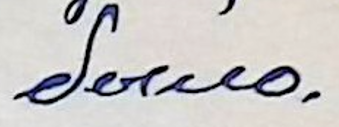

 38%|███▊      | 3/8 [00:00<00:00,  6.94it/s]

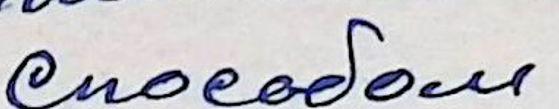

 50%|█████     | 4/8 [00:00<00:00,  6.96it/s]

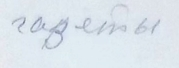

 62%|██████▎   | 5/8 [00:00<00:00,  5.35it/s]

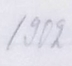

 75%|███████▌  | 6/8 [00:00<00:00,  6.18it/s]

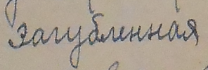

 88%|████████▊ | 7/8 [00:01<00:00,  6.40it/s]

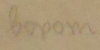

100%|██████████| 8/8 [00:01<00:00,  6.18it/s]

                                          image_path predicted_text
0  C:/Users/maill/WORK/Dataset/IMG_2024_08_08_10_...     ����������
1  C:/Users/maill/WORK/Dataset/IMG_2024_08_08_10_...        ������,
2  C:/Users/maill/WORK/Dataset/IMG_2024_08_08_11_...        ������.
3  C:/Users/maill/WORK/Dataset/IMG_2024_08_08_11_...        �������
4        C:/Users/maill/WORK/Dataset/5_1/img (5).jpg         гадеты
5       C:/Users/maill/WORK/Dataset/5_1/img (35).jpg           1902
6      C:/Users/maill/WORK/Dataset/Text_5/img_45.png    �����������
7      C:/Users/maill/WORK/Dataset/Text_2/img_49.png          ворот


In [31]:
image_paths = [
    "C:/Users/maill/WORK/Dataset/IMG_2024_08_08_10_30_17S/img_1.png",
    "C:/Users/maill/WORK/Dataset/IMG_2024_08_08_10_30_17S/img_81.png",
    "C:/Users/maill/WORK/Dataset/IMG_2024_08_08_11_02_54S/img_16.png",
    "C:/Users/maill/WORK/Dataset/IMG_2024_08_08_11_02_54S/img_21.png",
    "C:/Users/maill/WORK/Dataset/5_1/img (5).jpg",
    "C:/Users/maill/WORK/Dataset/5_1/img (35).jpg",
    "C:/Users/maill/WORK/Dataset/Text_5/img_45.png",
    "C:/Users/maill/WORK/Dataset/Text_2/img_49.png",
]

df_results = predict_batch(image_paths, model, processor, device)
print(df_results) 